EDA (Exploratory Data Analysis) on the **Data Science Salaries 2023** dataset.

In [1]:
import numpy as np
np.set_printoptions(linewidth=140)
import pandas as pd
pd.set_option('display.width', 140)
from pandas.api.types import is_numeric_dtype
from math import pi

import matplotlib.pyplot as plt
import seaborn as sns

from plotly import graph_objs as go
import plotly.express as px
import plotly.figure_factory as ff
from plotly.subplots import make_subplots
from plotly.offline import init_notebook_mode, iplot

## Extract Dataset Information

In [2]:
df = pd.read_csv('/kaggle/input/data-science-salaries-2023/ds_salaries.csv')
df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M
...,...,...,...,...,...,...,...,...,...,...,...
3750,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L
3751,2021,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L
3752,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S
3753,2020,EN,CT,Business Data Analyst,100000,USD,100000,US,100,US,L


In [3]:
# show numeric/category columns
num_cols = df.select_dtypes(include=(np.number)).columns
print(f"{len(num_cols)} Numeric Columns:\n{num_cols.to_list()}")

cat_cols = df.select_dtypes(exclude=(np.number)).columns
print(f"\n{len(cat_cols)} Category Columns:\n{cat_cols.to_list()}")

4 Numeric Columns:
['work_year', 'salary', 'salary_in_usd', 'remote_ratio']

7 Category Columns:
['experience_level', 'employment_type', 'job_title', 'salary_currency', 'employee_residence', 'company_location', 'company_size']


In [4]:
# show metadata info
def get_dataset_metadata(df):
    #num_cols = df.select_dtypes(include=(np.number))
    #skew = num_cols.skew()
    #kurtosis = num_cols.kurtosis()
    #cols = num_cols.columns.to_list()

    output = []
    for name in df.columns:
        col = df[name]
        output.append([name,
            str(col.dtype),
            col.isna().sum(),
            len(df) - np.sum(pd.isna(col)),
            col.nunique(),
            col.memory_usage(),
            col.skew() if is_numeric_dtype(col) else '',
            col.kurt() if is_numeric_dtype(col) else ''])
    output = pd.DataFrame(output,
        columns=['column', 'type', 'null', 'not-null', 'unique', 'mem', 'skew', 'kurtosis'])   
    return output
    
pd.options.display.max_rows = 500
output = get_dataset_metadata(df)
output

,column,type,null,not-null,unique,mem,skew,kurtosis
0,work_year,int64,0,3755,4,30168,-1.016374,1.127965
1,experience_level,object,0,3755,4,30168,,
2,employment_type,object,0,3755,4,30168,,
3,job_title,object,0,3755,93,30168,,
4,salary,int64,0,3755,815,30168,28.937932,1147.56739
5,salary_currency,object,0,3755,20,30168,,
6,salary_in_usd,int64,0,3755,1035,30168,0.536401,0.834006
7,employee_residence,object,0,3755,78,30168,,
8,remote_ratio,int64,0,3755,3,30168,0.149454,-1.925036
9,company_location,object,0,3755,72,30168,,


In [5]:
# show descriptive statistics (for all cols)
df.describe(include='all').fillna(' ').astype(str)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
count,3755.0,3755,3755,3755,3755.0,3755,3755.0,3755,3755.0,3755,3755
unique,,4,4,93,,20,,78,,72,3
top,,SE,FT,Data Engineer,,USD,,US,,US,M
freq,,2516,3718,1040,,3224,,3004,,3040,3153
mean,2022.3736351531293,,,,190695.57177097205,,137570.38988015978,,46.271637816245004,,
std,0.6914482342671989,,,,671676.5005079068,,63055.6252782241,,48.589050470587566,,
min,2020.0,,,,6000.0,,5132.0,,0.0,,
25%,2022.0,,,,100000.0,,95000.0,,0.0,,
50%,2022.0,,,,138000.0,,135000.0,,0.0,,
75%,2023.0,,,,180000.0,,175000.0,,100.0,,


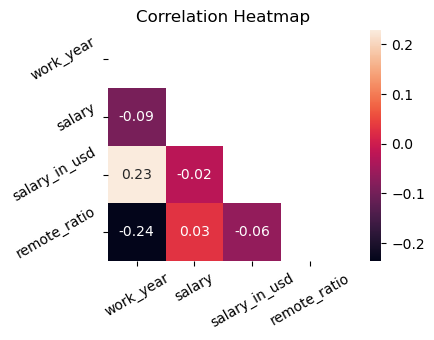

In [6]:
# make triangle correlation heatmap (num vars only)
def make_correlation_heatmap(df):
    plt.figure(figsize=(8,3))
    corr_matrix = df.corr(numeric_only=True)
    hm = sns.heatmap(
        corr_matrix, square=True, annot=True, fmt='.2f',
        mask=np.triu(np.ones_like(corr_matrix, dtype=bool)))
    hm.set_xticklabels(hm.get_xticklabels(), rotation=30)
    hm.set_yticklabels(hm.get_yticklabels(), rotation=30)           
    hm.set_title('Correlation Heatmap');

make_correlation_heatmap(df)

## Pandas Profiling

In [7]:
# install pandas-profiling (upgrade pip and pillow, to avoid some error)
!pip install --upgrade pip
!pip install --upgrade pillow
!pip install -U pandas-profiling

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.7/33.7 MB 32.3 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.10.1
    Uninstalling scipy-1.10.1:
      Successfully uninstalled scipy-1.10.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
momepy 0.6.0 requires shapely>=2, but you have shapely 1.8.5.post1 which is incompatible.
pymc3 3.11.5 requires numpy<1.22.2,>=1.15.0, but you have numpy 1.23.5 which is incompatible.
pymc3 3.11.5 requires scipy<1.8.0,>=1.7.3, but you have scipy 1.9.3 which is incompatible.


In [8]:
# this is all it takes to generate a nice report online
from ydata_profiling import ProfileReport

profile = ProfileReport(df,
    title="Data Science Salaries 2023 Dataset",
    explorative=True)
profile.to_notebook_iframe()

# save it also as a static downloadable HTML file
profile.to_file("my_report.html")

/opt/conda/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning:

numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.

/opt/conda/lib/python3.10/site-packages/visions/backends/shared/nan_handling.py:51: NumbaDeprecationWarning:

The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.



Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## Distribution of the Target Variable (salary_in_usd)

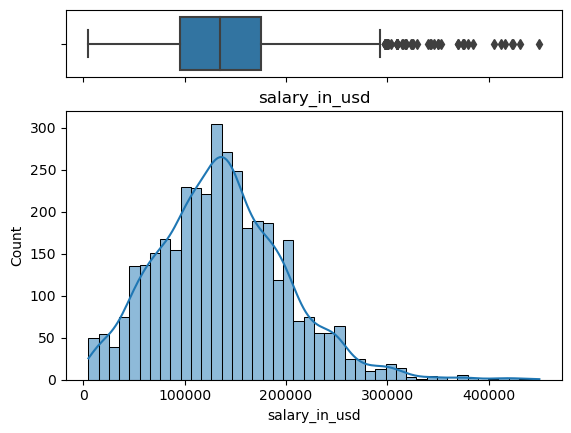

In [9]:
def plot_boxplot_and_hist(df, var):
    f, (ax_box, ax_hist) = plt.subplots(
        2, sharex=True, gridspec_kw={"height_ratios": (0.2, 0.8)})

    sns.boxplot(x=df[var], ax=ax_box)
    sns.histplot(data=df, x=var, ax=ax_hist, kde=True)
    ax_box.set(xlabel="")
    plt.title(var)
    plt.show()

plot_boxplot_and_hist(df, "salary_in_usd")


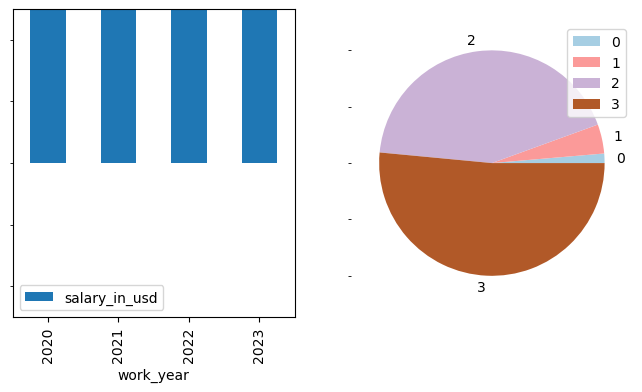

In [10]:
dfc = df.groupby(by=["work_year"], as_index=False)["salary_in_usd"].sum()

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=[8, 4], sharey=True)
dfc.plot.bar(x="work_year", y="salary_in_usd", ax=ax1)
dfc.plot.pie(colormap='Paired', x="work_year", y="salary_in_usd", ax=ax2)
plt.show()

## Show Total Annual Salaries per Experience Level

In [11]:
# map some column values for the experience_level
df2 = df.copy()
df2["experience_level"] = df2["experience_level"].map(
    {'EN': 'entry', 'EX': 'expert', 'MI': 'mid', 'SE': 'senior'})
df2

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,senior,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,mid,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,mid,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,senior,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,senior,FT,Data Scientist,120000,USD,120000,CA,100,CA,M
...,...,...,...,...,...,...,...,...,...,...,...
3750,2020,senior,FT,Data Scientist,412000,USD,412000,US,100,US,L
3751,2021,mid,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L
3752,2020,entry,FT,Data Scientist,105000,USD,105000,US,100,US,S
3753,2020,entry,CT,Business Data Analyst,100000,USD,100000,US,100,US,L


experience_level,entry,expert,mid,senior
work_year,,,,
2020,1322767,419833,2802071,2470329
2021,3019789,1861280,7554758,9204231
2022,9548747,7718672,36571321,168036725
2023,11243508,12222341,37215231,205365211


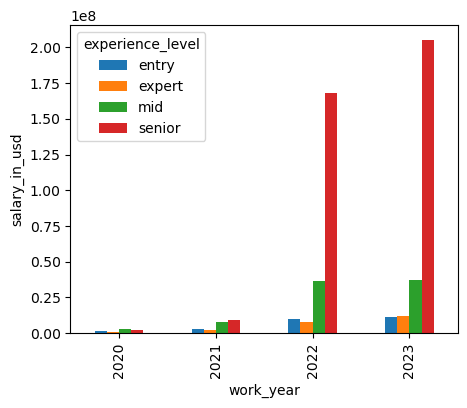

In [12]:
# create pivot table from 3 columns + show as bar chart
def show_bar_chart(df, rows_col, columns_col, values_col):
    
    # separate the columns
    dfc = df.groupby(
        by=[rows_col, columns_col],
        as_index=False)[values_col].sum()

    # show as a pivot table (make NaN/Nulls 0)
    dfc = dfc.pivot(index=rows_col,
        columns=columns_col, values=values_col)
    dfc = dfc.fillna(0).astype(int)

    # show as a bar chart
    dfc.plot(kind='bar',
        xlabel=rows_col, ylabel=values_col, figsize=(5,4))
    return dfc

dfc = show_bar_chart(df2, 
    "work_year", "experience_level", "salary_in_usd")
dfc